Name : Muzaffar Izamuddin
No Matriks: P166246

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('Question_1.csv')

In [3]:
df.head()

,Frequency,Angle_of_attack,Chord_length,Free_stream_velocity,Suction_side_displacement_thickness,Sound_pressure_level
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

X = df.drop('Sound_pressure_level', axis=1)
y = df['Sound_pressure_level']

#Question a
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=1
)

from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()  
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)  
X_test_scaled = scaler.transform(X_test) 
y_train_scaled = scaler.transform(X_train)  
y_test_scaled = scaler.transform(X_test) 

#Question b
tree = DecisionTreeRegressor(max_depth=6, min_samples_leaf=40, random_state=1)
tree.fit(X_train_scaled, y_train)
pred = tree.predict(X_test)
mse = mean_squared_error(y_test, pred)
print('Test MSE:', mse)
print('Test RMSE:', np.sqrt(mse))

Test MSE: 207.56421771981982
Test RMSE: 14.407089148048604


c:\Users\PC 14\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


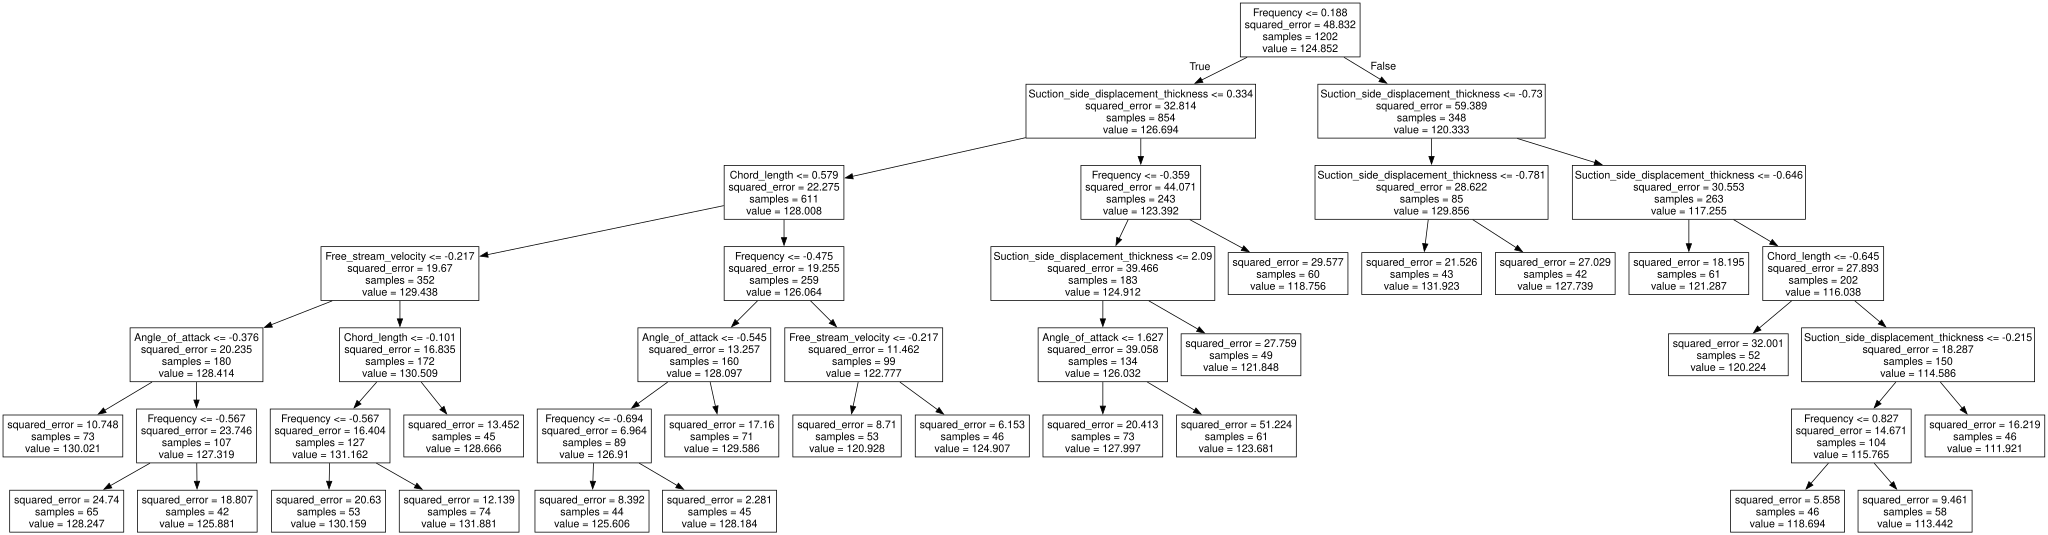

In [11]:
#Question c
import graphviz
from sklearn.tree import export_graphviz
export_graphviz(tree, 
                out_file = "PartB_tree.dot", 
                feature_names = X_train.columns)

with open("PartB_tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

Suction_side_displacement_thickness    0.458693
Frequency                              0.400168
Chord_length                           0.086238
Angle_of_attack                        0.033545
Free_stream_velocity                   0.021357
dtype: float64


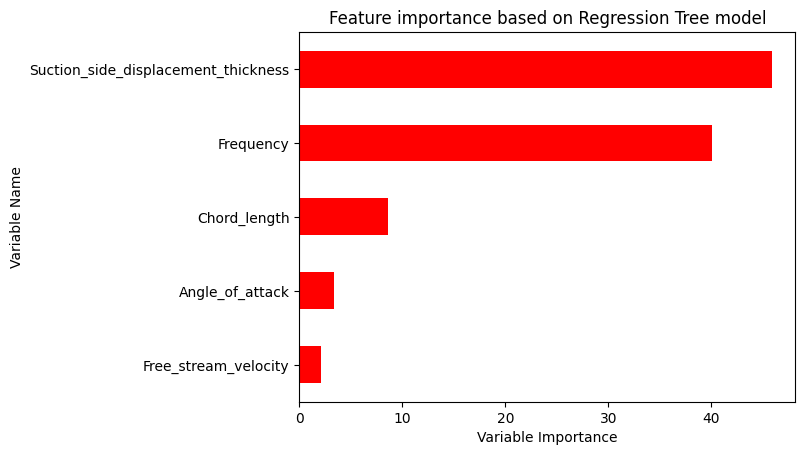

In [6]:
#Question c
importance = pd.Series(tree.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head())

Importance = pd.DataFrame({'Importance':tree.feature_importances_*100}, 
                          index = X.columns)

Importance.sort_values(by = 'Importance', 
                       axis = 0, 
                       ascending = True).plot(kind = 'barh', 
                                              color = 'r', )

plt.xlabel('Variable Importance')
plt.ylabel('Variable Name')
plt.title('Feature importance based on Regression Tree model')
plt.gca().legend_ = None
plt.show()

In [7]:
#Random forest question d

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

p = X.shape[1]
rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=1)
rf.fit(X_train_scaled, y_train)
print('Random forest MSE:', mean_squared_error(y_test, rf.predict(X_test)))

#Feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head())

Random forest MSE: 163.45527489942032
Suction_side_displacement_thickness    0.480482
Frequency                              0.406834
Chord_length                           0.066067
Angle_of_attack                        0.023882
Free_stream_velocity                   0.022736
dtype: float64


c:\Users\PC 14\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


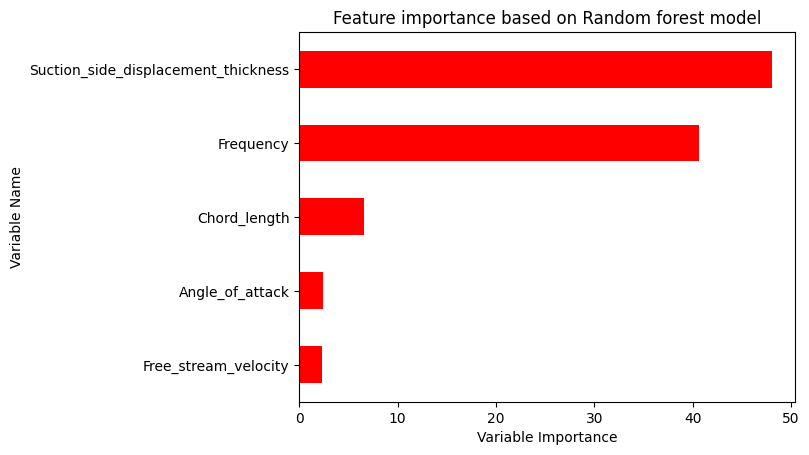

In [8]:
#Question e
Importance = pd.DataFrame({'Importance':rf.feature_importances_*100}, 
                          index = X.columns)

Importance.sort_values(by = 'Importance', 
                       axis = 0, 
                       ascending = True).plot(kind = 'barh', 
                                              color = 'r', )

plt.xlabel('Variable Importance')
plt.ylabel('Variable Name')
plt.title('Feature importance based on Random forest model')
plt.gca().legend_ = None
plt.show()

In [14]:
#Question f, MLP model

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score


mlp = MLPRegressor(hidden_layer_sizes=(32, 64, 8), activation='relu', max_iter=1000, random_state=0)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

print('MLP MSE:', mean_squared_error(y_test, mlp_pred))
print('MLP R2:', r2_score(y_test, mlp_pred))


MLP MSE: 1685.0766227290849
MLP R2: -38.67331624042164


We found that the MSE performance is quite bad at 1635 MSE which is worse than the decision trees model.

In [ ]:
#Question g, we use grid search to optimize number of neurons and layers
from sklearn.model_selection import GridSearchCV

params = {'hidden_layer_sizes': [(32,64, 16), (10, 10, 10), (10,10,10,10)]}
mlp = MLPRegressor(activation='relu', max_iter=1000, random_state=0)
model = GridSearchCV(mlp, params, cv=5)
model.fit(X_train,y_train)
model.best_params_

{'hidden_layer_sizes': (10, 10, 10, 10)}

In [24]:
model.cv_results_

{'mean_fit_time': array([0.11317039, 0.1982862 , 0.15611744]),
 'std_fit_time': array([0.03471896, 0.04696583, 0.02019088]),
 'mean_score_time': array([0.00085263, 0.00082321, 0.00081744]),
 'std_score_time': array([1.09178009e-05, 3.91086128e-05, 1.77883909e-05]),
 'param_hidden_layer_sizes': masked_array(data=[(32, 64, 16), (10, 10, 10), (10, 10, 10, 10)],
              mask=[False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'hidden_layer_sizes': (32, 64, 16)},
  {'hidden_layer_sizes': (10, 10, 10)},
  {'hidden_layer_sizes': (10, 10, 10, 10)}],
 'split0_test_score': array([-23.49350749, -23.58551973, -23.8466533 ]),
 'split1_test_score': array([-23.40727287, -25.47182624, -22.14817737]),
 'split2_test_score': array([-25.57140721, -24.6416475 , -26.55140752]),
 'split3_test_score': array([-21.19699976, -20.22575129, -20.98469125]),
 'split4_test_score': array([-21.10626522, -20.36493412, -19.78009328]),
 'mean_test_score': array([-22.95509

In [25]:
mlp = MLPRegressor(hidden_layer_sizes=(10,10,10,10), activation='relu', max_iter=1000, random_state=0)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

print('MLP MSE:', mean_squared_error(y_test, mlp_pred))
print('MLP R2:', r2_score(y_test, mlp_pred))


MLP MSE: 1131.2746879515423
MLP R2: -25.634645478137152


In [26]:
params = {'hidden_layer_sizes': [(10,10,10,10), (50, 50, 50,50), (10,10,10,10,10)]}
mlp = MLPRegressor(activation='relu', max_iter=10000, random_state=0)
model = GridSearchCV(mlp, params, cv=5)
model.fit(X_train,y_train)
model.best_params_

{'hidden_layer_sizes': (10, 10, 10, 10, 10)}

In [27]:
mlp = MLPRegressor(hidden_layer_sizes=(10,10,10,10,10), activation='relu', max_iter=1000, random_state=0)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

print('MLP MSE:', mean_squared_error(y_test, mlp_pred))
print('MLP R2:', r2_score(y_test, mlp_pred))


MLP MSE: 1176.8524322873152
MLP R2: -26.707724435003627


In [28]:
params = {'hidden_layer_sizes': [(10,10,10,10,10), (50, 50, 50,50,50), (10,10,10,10,10,10)]}
mlp = MLPRegressor(activation='relu', max_iter=10000, random_state=0)
model = GridSearchCV(mlp, params, cv=5)
model.fit(X_train,y_train)
model.best_params_

{'hidden_layer_sizes': (10, 10, 10, 10, 10, 10)}

In [35]:
mlp = MLPRegressor(hidden_layer_sizes=(10,10,10,10,10,10), activation='relu', max_iter=1000, random_state=0)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

print('MLP MSE:', mean_squared_error(y_test, mlp_pred))
print('MLP R2:', r2_score(y_test, mlp_pred))

MLP MSE: 1015.4569151164441
MLP R2: -22.907840615990004


Lets check if another activation function could improve our model

In [38]:
params = {'hidden_layer_sizes': [(10,10,10,10,10,10)],
          'activation': ['relu', 'tanh']}
mlp = MLPRegressor(max_iter=10000, random_state=0)
model = GridSearchCV(mlp, params, cv=5)
model.fit(X_train_scaled,y_train)
model.best_params_

{'activation': 'relu', 'hidden_layer_sizes': (10, 10, 10, 10, 10, 10)}

relu is still the best from the results above.

What we can observe, from the various Grid search conducted Relu with 6 hidden layers all valued at 10 is the best we can achieve. The MLP model with the 'activation': 'relu' and 'hidden_layer_sizes': (10, 10, 10, 10, 10, 10) is able to achieve below performance with MSE = 1015

In comparison:

Decision Tree MSE : 207.56
Random Forest MSE : 163.45
Initial MLP MSE   : 1685.07
Tuned MLP MSE     : 1015.45

The MLP tuning is able to bring down the MSE by a large number however it still cannot match the random forest performance. The MLP model may need more tuning in order to get the same result as the random forest model.


